# Fase 3 - Modelado horario (baseline, SARIMAX-Fourier, Prophet)

Pronosticamos la demanda **horaria**. La lógica vive en `src/` y aquí la usamos. Tres modelos:
1. **Baseline naive estacional** (misma hora de la semana pasada) - la vara de medir.
2. **SARIMAX + Fourier** - la estacionalidad múltiple (diaria/semanal/anual) entra como regresores
   de Fourier, así SARIMA compite de forma justa (antes, con `m` semanal, quedaba muy por debajo).
3. **Prophet** - estacionalidad nativa.

In [1]:
# Bootstrap: ejecutable desde cualquier carpeta (jupyter nbconvert).
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "config.yaml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from src.config import load_config, path
from src import data, models

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"})
cfg = load_config(); REPORTS = path(cfg["paths"]["reports"])

s = data.load_series(cfg)
train, test = data.train_test(s, cfg)
print(f"train {len(train):,}h | test {len(test):,}h ({test.index.min()} -> {test.index.max()})")

train 26,280h | test 336h (2018-07-20 01:00:00 -> 2018-08-03 00:00:00)


## Baseline + SARIMAX-Fourier + Prophet sobre el test

In [2]:
res, fcs = {}, {}
fcs["Seasonal-Naive"] = models.seasonal_naive(s, test.index, cfg["baseline"]["naive_period_hours"])
res["Seasonal-Naive"] = models.metrics(test, fcs["Seasonal-Naive"])

sarimax, origin = models.fit_sarimax_fourier(train, cfg)
fcs["SARIMAX-Fourier"] = models.sarimax_predict(sarimax, origin, test.index, cfg)
res["SARIMAX-Fourier"] = models.metrics(test, fcs["SARIMAX-Fourier"])

prophet = models.fit_prophet(train)
fcs["Prophet"] = models.prophet_predict(prophet, test.index)
res["Prophet"] = models.metrics(test, fcs["Prophet"])

tab = pd.DataFrame(res).T.round(2); tab

Importing plotly failed. Interactive plots will not work.


18:09:49 - cmdstanpy - INFO - Chain [1] start processing


18:10:35 - cmdstanpy - INFO - Chain [1] done processing


,mae,rmse,mape
Seasonal-Naive,3276.64,4244.87,9.21
SARIMAX-Fourier,4285.76,5331.21,11.09
Prophet,3531.65,4237.55,10.92


## SARIMAX y Prophet: pronóstico vs real

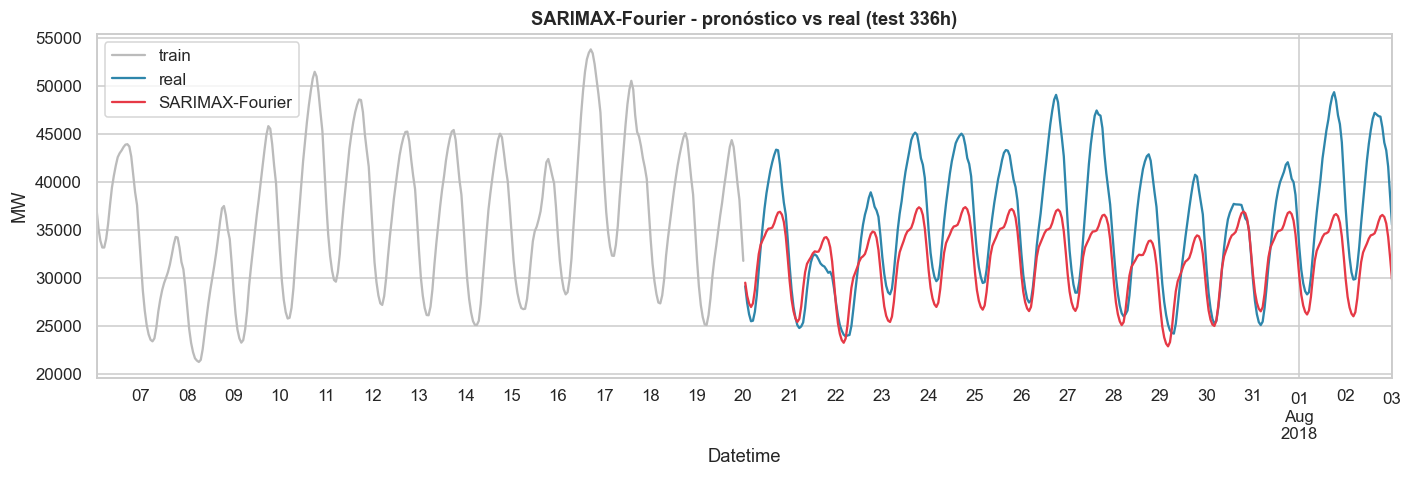

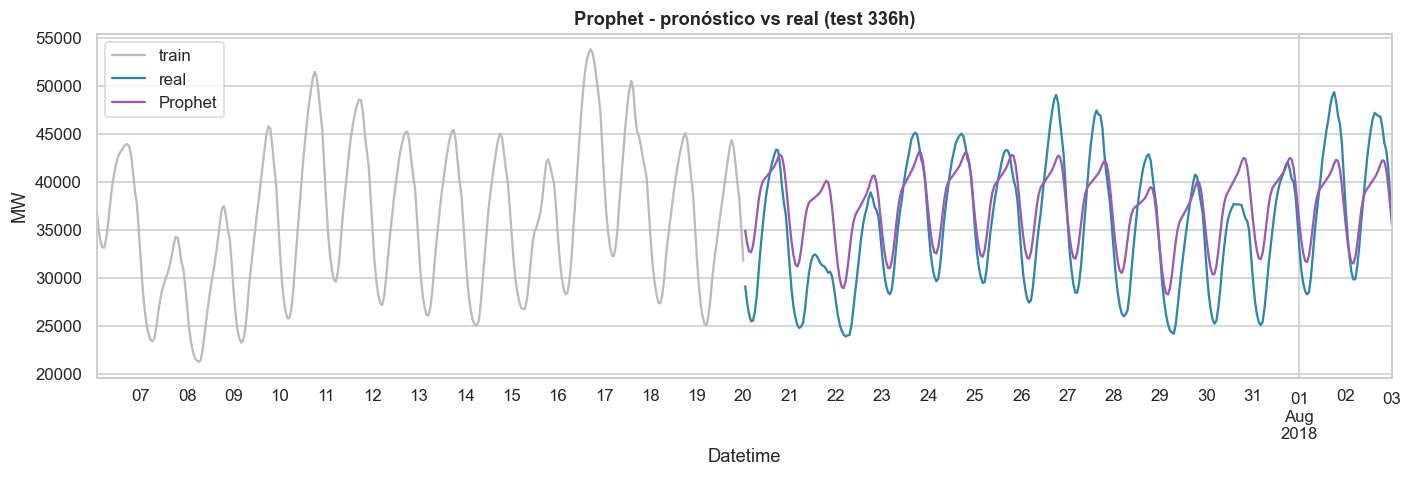

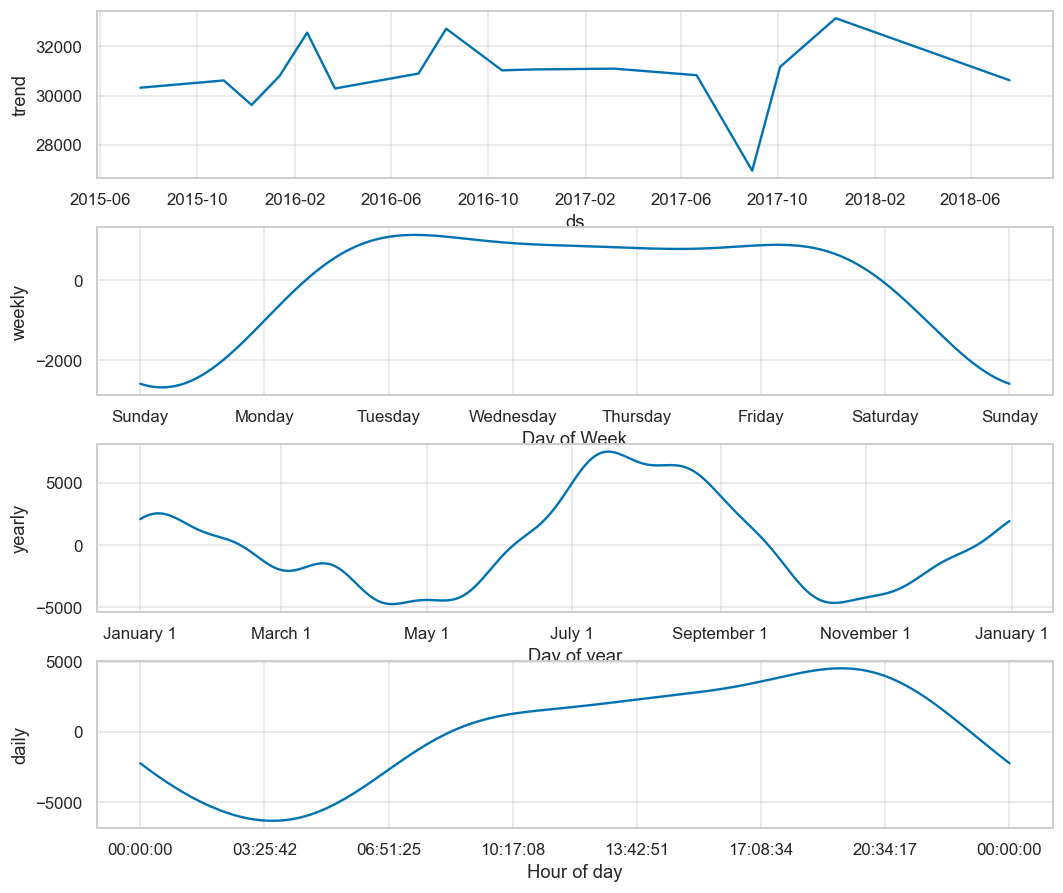

In [3]:
ctx = train.iloc[-336:]   # últimas 2 semanas de train como contexto
for nombre, fname, color in [("SARIMAX-Fourier","06_sarimax_forecast.png","#E63946"),
                             ("Prophet","08_prophet_forecast.png","#9b59b6")]:
    fig, ax = plt.subplots(figsize=(13,4.5))
    ctx.plot(ax=ax, color="#bbb", label="train")
    test.plot(ax=ax, color="#2E86AB", label="real")
    fcs[nombre].plot(ax=ax, color=color, label=nombre)
    ax.set_title(f"{nombre} - pronóstico vs real (test {len(test)}h)"); ax.set_ylabel("MW"); ax.legend()
    fig.tight_layout(); fig.savefig(REPORTS/fname, bbox_inches="tight"); plt.show()

fig = prophet.plot_components(prophet.predict(prophet.make_future_dataframe(periods=0, freq="h")))
fig.set_size_inches(10,8); fig.savefig(REPORTS/"07_prophet_components.png", bbox_inches="tight"); plt.show()

## Comparación de modelos

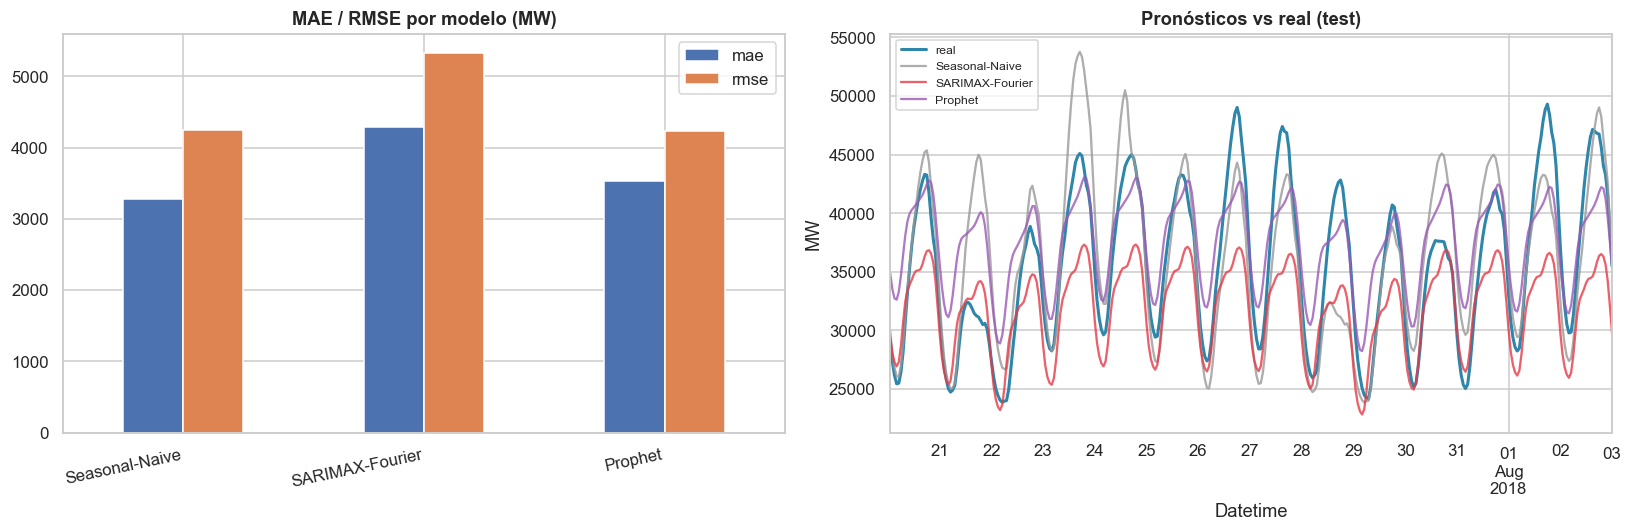

                     mae     rmse   mape
Seasonal-Naive   3276.64  4244.87   9.21
SARIMAX-Fourier  4285.76  5331.21  11.09
Prophet          3531.65  4237.55  10.92

Nota: una sola ventana de test es ruidosa; el backtesting walk-forward (notebook 04) da una lectura robusta.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
tab[["mae","rmse"]].plot.bar(ax=ax[0]); ax[0].set_title("MAE / RMSE por modelo (MW)")
ax[0].set_xticklabels(tab.index, rotation=12, ha="right")
test.plot(ax=ax[1], color="#2E86AB", lw=2, label="real")
for nombre,color in [("Seasonal-Naive","#999"),("SARIMAX-Fourier","#E63946"),("Prophet","#9b59b6")]:
    fcs[nombre].plot(ax=ax[1], alpha=.8, label=nombre, color=color)
ax[1].set_title("Pronósticos vs real (test)"); ax[1].set_ylabel("MW"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS/"09_model_comparison.png", bbox_inches="tight"); plt.show()
print(tab.to_string())
print("\nNota: una sola ventana de test es ruidosa; el backtesting walk-forward (notebook 04) da una lectura robusta.")

## Pronóstico a 30 días (Prophet, reentrenado con toda la ventana)

18:10:45 - cmdstanpy - INFO - Chain [1] start processing


18:11:35 - cmdstanpy - INFO - Chain [1] done processing


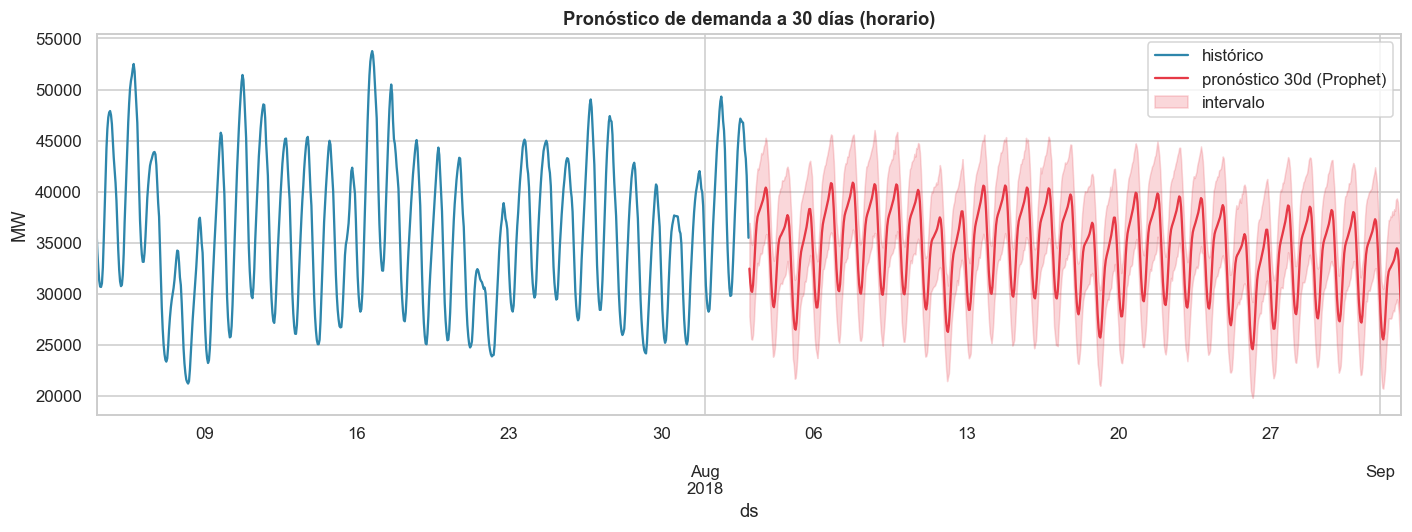

In [5]:
full = data.recent_window(s, cfg)
mf = models.fit_prophet(full)
H = cfg["forecast"]["horizon_hours"]
fut_idx = pd.date_range(full.index[-1] + pd.Timedelta("1h"), periods=H, freq="h")
fc = mf.predict(pd.DataFrame({"ds": fut_idx})).set_index("ds")

fig, ax = plt.subplots(figsize=(13,5))
full.iloc[-720:].plot(ax=ax, color="#2E86AB", label="histórico")
fc["yhat"].plot(ax=ax, color="#E63946", label="pronóstico 30d (Prophet)")
ax.fill_between(fut_idx, fc["yhat_lower"], fc["yhat_upper"], color="#E63946", alpha=.2, label="intervalo")
ax.set_title("Pronóstico de demanda a 30 días (horario)"); ax.set_ylabel("MW"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"10_forecast_30days.png", bbox_inches="tight"); plt.show()

## Conclusiones

- En horario, el **naive semanal** es un baseline durísimo (copia la semana anterior, que para
  energía es casi inmejorable a corto plazo). Aun así, **Prophet queda a la par** (RMSE algo menor)
  y **SARIMAX-Fourier ya es competitivo** (~11% MAPE), no el desastre del v1.0.0 (21% en diario):
  los Fourier le dieron la estacionalidad múltiple que le faltaba.
- Una sola ventana de 14 días es **ruidosa**; el **backtesting walk-forward** (notebook 04) mide
  el rendimiento de forma robusta antes de elegir.